# Measurement x=15, y=0, z=0

### Imports

In [58]:

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


from ppvm_py.utils import load_object

from ppvm_py.yz_slice_utils import find_closest_coordinate_index

from ppvm_py.plotting import plot_timeseries
from ppvm_py.plotting import plot_heatmap
from ppvm_py.plotting import generate_2d_video

from ppvm_py.data_processing.patt_fld8v import print_xyz_slice_example_from_parsed_data

from ppvm_py.data_processing.utils import create_index_to_coord_map

from ppvm_py.feature_generation.sdc import symmetric_difference_coefficient
from ppvm_py.feature_generation.sdc import compute_symmetric_difference_coefficients_with_index_to_coord_map

from ppvm_py.feature_generation.pdm import pdm_approximated_velocity
from ppvm_py.feature_generation.pdm import compute_pdm_approximated_velocities_with_index_to_coord_map

### General Args

In [59]:
# IMPORTANT: Restart Kernel when swapping datasets to reload them!
Ha = 1000

if Ha == 300:
    patt_fld8v_folder_path = Path("../../../../data/4pi_re1000_ha300.360_ch28.p1/patt_fld8v/")
elif Ha == 1000:
    patt_fld8v_folder_path = Path("../../../../data/4pi_re1000_ha1000.384.pi/patt_fld8v/")

fld_path = patt_fld8v_folder_path / Path("pkl/patt_fld8v.pkl")

# Estimates from evaluations
sigma = -1  # According to the results here.
B_z = -1  # According to the results here.

animation_folder = Path(f"animations/feature_pdm/")

truncate_data = True
truncate_at_snapshot = 20  # Including indices 0 to (truncate_at_snapshot - 1)

test_size = 0.3

### Preamble

In [60]:
mean_mse = {}  # Dict for gathering mean-squared-errors.

### Load Data

In [61]:
if 'fld_data' not in locals():
    fld_data = load_object(fld_path)
    if truncate_data:
        fld_data['timeseries'] = fld_data['timeseries'][:truncate_at_snapshot]
    fld_data['index_to_coord_map'] = create_index_to_coord_map(fld_data['coord_to_index_map'])
print_xyz_slice_example_from_parsed_data(fld_data)

N = fld_data['timeseries'].shape[0]  # n snapshots
n_x = fld_data['timeseries'].shape[1]
n_y = fld_data['timeseries'].shape[2]
n_z = fld_data['timeseries'].shape[3]
n_v = fld_data['timeseries'].shape[4]
n_grid_points = n_x * n_y * n_z

The 3D data looks as follows:
N (number of snapshots) = 20
n_x (grid depth) = 577, n_y (grid height) = 97, n_z (grid width) = 97, n_v (number of variables) = 8
Labels:
['vx', 'vy', 'vz', 'jx', 'jy', 'jz', 'P', 'F']
Preview of the first snapshot (first 2 x, first 2 y, first 2 z) with coordinates:
  (x=0.00, y=-1.00, z=-1.00): [ 0.          0.          0.          0.          0.          0.
  0.00070366 -0.1506608 ]
  (x=0.00, y=-1.00, z=-0.99): [ 0.          0.          0.          0.          0.         -0.01773967
  0.00071547 -0.1506508 ]
  (x=0.00, y=-0.99, z=-1.00): [ 0.         0.         0.         0.         0.3698478  0.
  0.0007184 -0.1515782]
  (x=0.00, y=-0.99, z=-0.99): [ 0.          0.          0.          0.          0.4032355  -0.00119388
  0.00074057 -0.1516712 ]
  (x=0.02, y=-1.00, z=-1.00): [ 0.000000e+00  0.000000e+00  0.000000e+00 -1.667895e+00  0.000000e+00
  0.000000e+00  6.524514e-04 -1.327779e-01]
  (x=0.02, y=-1.00, z=-0.99): [ 0.000000e+00  0.000000e+00  0.000

### Define Train and Test Set

In [ ]:
fld_data_train, fld_data_test = train_test_split(
    fld_data['timeseries'],
    test_size=test_size,
    shuffle=False,
)
n_timesteps_train = fld_data_train.shape[0]
n_timesteps_test = fld_data_test.shape[0]

### Define $y_{true}$

In [ ]:
y_true_train = fld_data_train[
    ...,
    fld_data['labels'].index('vx'):fld_data['labels'].index('vx') + 1,
]
y_true_train = y_true_train.reshape(n_timesteps_train, -1)

y_true_test = fld_data_test[
    ...,
    fld_data['labels'].index('vx'):fld_data['labels'].index('vx') + 1,
]
y_true_test = y_true_test.reshape(n_timesteps_test, -1)


# Every grid point is a feature. The scaling must not be different between these features => train SS on all data together.
ss_y_true_trainer = StandardScaler()
ss_y_true_trainer.fit(y_true_train.reshape(-1, 1))

# Create on SS that works on all features separately with the training params from the SS on all data.
ss_y_true = StandardScaler()

ss_y_true.scale_ = np.full(
    n_grid_points,
    ss_y_true_trainer.scale_[0],
)
ss_y_true.mean_ = np.full(
    n_grid_points,
    ss_y_true_trainer.mean_[0],
)
ss_y_true.var_ = np.full(
    n_grid_points,
    ss_y_true_trainer.var_[0],
)
ss_y_true.n_features_in_ = n_grid_points
ss_y_true.n_samples_seen_ = np.full(
    n_grid_points,
    ss_y_true_trainer.n_samples_seen_,
)


# trans y_true
y_true_train = ss_y_true.transform(
    y_true_train,
    copy=False,
    )
y_true_test = ss_y_true.transform(
    y_true_test,
    copy=False,
    )

### Precompute Features

In [ ]:
approx_part_phi_y_train= compute_symmetric_difference_coefficients_with_index_to_coord_map(
    fld_data_train[..., fld_data['labels'].index('F')],
    direction_axis=2,
    index_to_coord_map=fld_data['index_to_coord_map'],
)
approx_part_phi_y_train = approx_part_phi_y_train.reshape(n_timesteps_train, -1)

approx_part_phi_y_test= compute_symmetric_difference_coefficients_with_index_to_coord_map(
    fld_data_test[..., fld_data['labels'].index('F')],
    direction_axis=2,
    index_to_coord_map=fld_data['index_to_coord_map'],
)
approx_part_phi_y_test = approx_part_phi_y_test.reshape(n_timesteps_test, -1)


v_x_pdm_train = approx_part_phi_y_train / B_z
v_x_pdm_train = ss_y_true.transform(
    v_x_pdm_train,
    copy=False,
)

v_x_pdm_test = approx_part_phi_y_test / B_z
v_x_pdm_test = ss_y_true.transform(
    v_x_pdm_test,
    copy=False,
)

j_y_test = fld_data_test[..., fld_data['labels'].index('jy')]
j_y_test = j_y_test.reshape(n_timesteps_test, -1)

### Potential Difference Method (SDC) Benchmark
Assume we know $j_y$, but we are restricted the the potential measurements $\phi$ from our DNS.

A simple feature used in the experiments is the symmetric difference coefficient $\frac{\Delta{\phi}}{\Delta{y}}$ to approximate $\frac{\partial{\phi}}{\partial{y}}$. This is also called *Potential Difference Method*. With this and $j_y$, Ohm's law can be approximated to calculate $v_x$.

We use the smallest difference possible to calculate $\frac{\Delta{\phi}}{\Delta{y}}$. With this, we have a benchmark for methods that use the Symmetric Difference Coefficient as singular feature.

##### Testing

In [65]:
v_x_sdc_test = (approx_part_phi_y_test - (j_y_test / sigma)) / B_z
y_pred_sdc_test = ss_y_true.transform(
    v_x_sdc_test,
    copy=False,
)

In [66]:
mse_sdc = mean_squared_error(
    y_true_test,
    y_pred_sdc_test,
    multioutput='raw_values',
)

mean_mse_sdc = np.mean(mse_sdc)
mean_mse['PDM Benchmark'] = mean_mse_sdc
print(f"mean(mse(pdm_bench)) = {mean_mse_sdc}")

# i_start = 0
# generate_2d_video(
#     data=mse_sdc.reshape(n_x, n_y, n_z),
#     output_file_path=animation_folder / Path("mse_pdm_bench.gif"),
#     fps=10,
#     xlabel="Y Axis",
#     ylabel="Z Axis",
#     title_pattern="X Index: " + f"{i_start} + " + " {}" if i_start != 0 else "X Index: {}",
#     vmax=0.05,
# )

mean(mse(pdm_bench)) = 0.001172356293034327


### Potential Difference Method (PDM)

##### Testing

In [67]:
mse_pdm = mean_squared_error(
    y_true_test,
    v_x_pdm_test,
    multioutput='raw_values',
    )

mean_mse_pdm = np.mean(mse_pdm)
mean_mse['PDM'] = mean_mse_pdm
print(f"mean(mse(pdm)) = {mean_mse_pdm}")

# i_start = 0
# generate_2d_video(
#     data=mse_pdm.reshape(n_x, n_y, n_z),
#     output_file_path=animation_folder / Path("mse_pdm.gif"),
#     fps=10,
#     xlabel="Y Axis",
#     ylabel="Z Axis",
#     title_pattern="X Index: " + f"{i_start} + " + " {}" if i_start != 0 else "X Index: {}",
#     vmax=0.05,
# )

mean(mse(pdm)) = 0.024761642859476532


### Linearly Scaled PDM (cPDM)

##### Training

In [72]:
model = LinearRegression(fit_intercept=False)
model.fit(
    X = v_x_pdm_train.reshape(-1, 1),
    y = y_true_train.reshape(-1, 1),
)
c =  1 / model.coef_[0, 0]

##### Testing

In [ ]:
y_pred_c_pdm_test = v_x_pdm_test / c

mse_c_pdm = mean_squared_error(
    y_true_test,
    y_pred_c_pdm_test,
    multioutput='raw_values',
)
mean_mse_c_pdm = np.mean(mse_c_pdm)
mean_mse['c-PDM'] = mean_mse_c_pdm
print(f"mean(mse(c-PDM)) = {mean_mse_c_pdm}")

# i_start = 0
# generate_2d_video(
#     data=mse_c_pdm.reshape(n_x, n_y, n_z),
#     output_file_path=animation_folder / Path("mse_c_pdm.gif"),
#     fps=10,
#     xlabel="Y Axis",
#     ylabel="Z Axis",
#     title_pattern="X Index: " + f"{i_start} + " + " {}" if i_start != 0 else "X Index: {}",
#     vmax=0.05,
# )

mean(mse(c-PDM)) = 0.024723497398672366
Video saved to
C:\Users\hydro\Documents\phd\nuclear_fusion_cooling\potential_probe_velocity_measuring\potential_probe_velocity_measuring\notebooks\3d\animations\feature_pdm\mse_c_pdm.gif


### Linear Regression on Feature: PDM

##### Training

In [75]:
model = LinearRegression()
model.fit(
    X = v_x_pdm_train.reshape(-1, 1),
    y = y_true_train.reshape(-1, 1),
);

##### Testing

mse(LR-PDM) = 0.26662418028478063


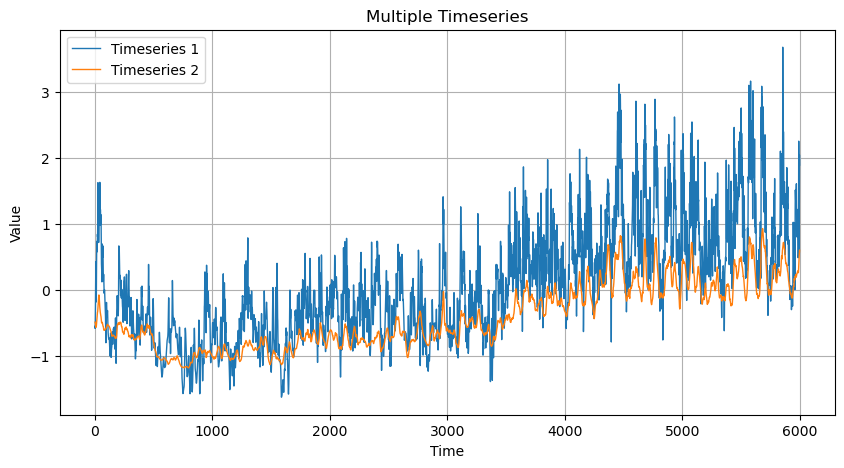

In [ ]:
y_pred_lr_pdm_test = model.predict(
    v_x_pdm_test.reshape(-1, 1),
).reshape(
    n_timesteps_test,
    n_grid_points,
)
mse_lr_pdm = mean_squared_error(y_true_test, y_pred_lr_pdm_test)
mean_mse['LR-PDM'] = mse_lr_pdm
print(f"mse(LR-PDM) = {mse_lr_pdm}")
plot_timeseries(
    data_list=[
        y_true_test,
        y_pred_c_pdm_test,
        ],
    )

### Comparison

In [ ]:
mean_mse

{'General Benchmark': 0.010206003487330495,
 'PDM Benchmark': 0.04156472236966485,
 'PDM': 0.6850771111809714,
 'c-PDM': 0.47102987674548935,
 'LR-PDM': 0.26662418028478063}